# Exercise 6 - Markov Chain Monte Carlo (MCMC)

Sample from distributions known only up to a normalising constant, using Metropolis-Hastings
and Gibbs sampling. MCMC samples are *dependent*, so each chain uses a burn-in and keeps only
every $k$-th state before the $\chi^2$ goodness-of-fit test, which assumes independent observations.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, norm
from scipy.special import gammaln

rng = np.random.default_rng(2026)
plt.rcParams["figure.figsize"] = (10, 4)


def chisq_gof(obs, probs, min_expected=5):
    """Chi^2 goodness-of-fit; pool cells with expected count < min_expected."""
    obs = np.asarray(obs, float)
    e = obs.sum() * np.asarray(probs, float)
    keep = e >= min_expected
    o = list(obs[keep]) + ([obs[~keep].sum()] if (~keep).any() else [])
    e = list(e[keep]) + ([e[~keep].sum()] if (~keep).any() else [])
    o, e = np.array(o), np.array(e)
    T = float(np.sum((o - e) ** 2 / e))
    df = len(e) - 1
    return dict(stat=T, df=df, p=float(chi2.sf(T, df)))

## Part 1 - Truncated Poisson via Metropolis

$P(i)=c\,A^i/i!,\ i=0,\dots,m$, with $A=8,\ m=10$ (Exercise 4 values). The random-walk proposal
$y=x\pm1$ is symmetric, so the acceptance probability is $\alpha=\min\!\big(1,\,g(y)/g(x)\big)$
with $g(i)=A^i/i!$; the unknown constant $c$ cancels.

In [2]:
A, m = 8.0, 10
logg = lambda i: i * np.log(A) - gammaln(i + 1)        # log of unnormalised g(i) = A^i / i!


def mh_chain(logg, lo, hi, n_keep, burn=2000, thin=50, rng=rng):
    """Random-walk Metropolis on integers {lo,...,hi} with proposal y = x +/- 1."""
    x = (lo + hi) // 2
    out = np.empty(n_keep, int)
    t = kept = 0
    while kept < n_keep:
        y = x + (1 if rng.random() < 0.5 else -1)
        if lo <= y <= hi and rng.random() < np.exp(logg(y) - logg(x)):
            x = y
        t += 1
        if t > burn and t % thin == 0:
            out[kept] = x
            kept += 1
    return out


s = mh_chain(logg, 0, m, 10_000)
states = np.arange(m + 1)
w = np.exp(logg(states))
target = w / w.sum()
obs = np.bincount(s, minlength=m + 1)
r = chisq_gof(obs, target)
print(f"chi2 = {r['stat']:.2f}   df = {r['df']}   p = {r['p']:.3f}")

chi2 = 11.55   df = 10   p = 0.317


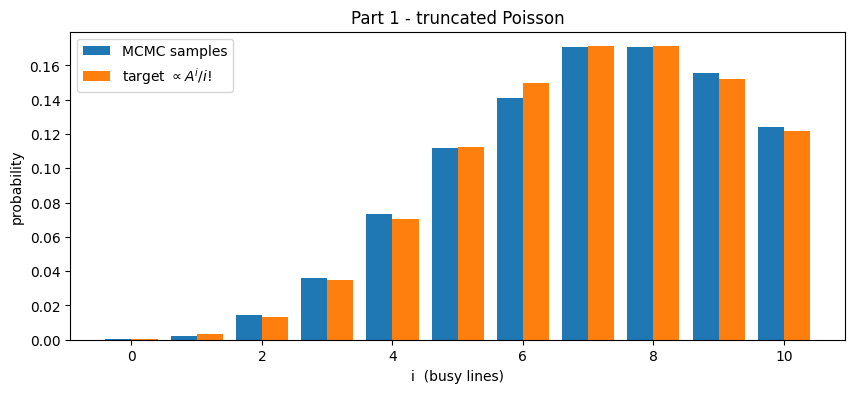

In [3]:
plt.bar(states - 0.2, obs / obs.sum(), 0.4, label="MCMC samples")
plt.bar(states + 0.2, target, 0.4, label=r"target $\propto A^i/i!$")
plt.xlabel("i  (busy lines)")
plt.ylabel("probability")
plt.title("Part 1 - truncated Poisson")
plt.legend()
plt.show()

## Part 2 - Joint occupancy

$P(i,j)=c\,\dfrac{A_1^i}{i!}\dfrac{A_2^j}{j!},\ 0\le i+j\le m$, with $A_1=A_2=4,\ m=10$.
Three samplers for the same target: **(a)** direct MH, **(b)** coordinatewise MH, **(c)** Gibbs.
For Gibbs the conditionals are again truncated Poissons:
$P(i\mid j)\propto A_1^i/i!$ on $\{0,\dots,m-j\}$ and $P(j\mid i)\propto A_2^j/j!$ on $\{0,\dots,m-i\}$.

In [4]:
A1 = A2 = 4.0
M = 10
logG = lambda i, j: i * np.log(A1) - gammaln(i + 1) + j * np.log(A2) - gammaln(j + 1)
valid = [(i, j) for i in range(M + 1) for j in range(M + 1) if i + j <= M]
idx = {state: k for k, state in enumerate(valid)}
wv = np.array([np.exp(logG(i, j)) for i, j in valid])
target2 = wv / wv.sum()


def gof_joint(samples):
    obs = np.zeros(len(valid))
    for state in samples:
        obs[idx[state]] += 1
    return chisq_gof(obs, target2)


N, BURN, THIN = 10_000, 2000, 50

In [5]:
def mh_direct(rng=rng):
    """(a) 2-D random-walk Metropolis: move one randomly chosen coordinate by +/-1."""
    i = j = 0
    out = []
    t = 0
    while len(out) < N:
        if rng.random() < 0.5:
            ni, nj = i + (1 if rng.random() < 0.5 else -1), j
        else:
            ni, nj = i, j + (1 if rng.random() < 0.5 else -1)
        if ni >= 0 and nj >= 0 and ni + nj <= M and rng.random() < np.exp(logG(ni, nj) - logG(i, j)):
            i, j = ni, nj
        t += 1
        if t > BURN and t % THIN == 0:
            out.append((i, j))
    return out


def mh_coordwise(rng=rng):
    """(b) coordinatewise Metropolis: a +/-1 step on i, then a +/-1 step on j, each sweep."""
    i = j = 0
    out = []
    t = 0
    while len(out) < N:
        ni = i + (1 if rng.random() < 0.5 else -1)
        if ni >= 0 and ni + j <= M and rng.random() < np.exp(logG(ni, j) - logG(i, j)):
            i = ni
        nj = j + (1 if rng.random() < 0.5 else -1)
        if nj >= 0 and i + nj <= M and rng.random() < np.exp(logG(i, nj) - logG(i, j)):
            j = nj
        t += 1
        if t > BURN and t % THIN == 0:
            out.append((i, j))
    return out


def draw_trunc_pois(A, hi, rng=rng):
    """Draw k with P(k) proportional to A^k / k!, k = 0,...,hi (a truncated Poisson)."""
    k = np.arange(hi + 1)
    w = np.exp(k * np.log(A) - gammaln(k + 1))
    return rng.choice(k, p=w / w.sum())


def gibbs(rng=rng):
    """(c) Gibbs sampler: conditionals i|j and j|i are truncated Poissons (see markdown)."""
    i = j = 0
    out = []
    t = 0
    while len(out) < N:
        i = draw_trunc_pois(A1, M - j)
        j = draw_trunc_pois(A2, M - i)
        t += 1
        if t > BURN and t % THIN == 0:
            out.append((i, j))
    return out


for name, fn in [("(a) direct MH", mh_direct),
                 ("(b) coordinatewise", mh_coordwise),
                 ("(c) Gibbs", gibbs)]:
    r = gof_joint(fn())
    print(f"{name:20s} chi2 = {r['stat']:6.2f}   df = {r['df']}   p = {r['p']:.3f}")

(a) direct MH        chi2 =  68.35   df = 61   p = 0.242


(b) coordinatewise   chi2 =  55.90   df = 61   p = 0.661


(c) Gibbs            chi2 =  65.01   df = 61   p = 0.339


## Part 3 - Bayesian posterior for $X_i\sim N(\Theta,\Psi)$

Prior: $(\Xi,\Gamma)=(\log\Theta,\log\Psi)$ is standard bivariate normal with $\rho=\tfrac12$.
Posterior $\propto$ prior $\times$ likelihood. We run random-walk MH in $(\xi,\gamma)$,
where the prior keeps its bivariate-normal form and the walk is unconstrained;
$\theta=e^{\xi},\ \psi=e^{\gamma}$. The constant cancels in $\alpha$.

In [6]:
rho = 0.5
xi0, gam0 = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]])   # (a) draw (xi, gamma)
theta, psi = np.exp(xi0), np.exp(gam0)                              #     (b) true (theta, psi)
print(f"prior draw:  theta = {theta:.4f}   psi = {psi:.4f}")

prior draw:  theta = 0.2148   psi = 0.2009


**(c) Posterior.** $g(\xi,\gamma)=\exp\!\Big(-\dfrac{\xi^2-2\rho\xi\gamma+\gamma^2}{2(1-\rho^2)}\Big)\,\prod_{i=1}^n N(x_i;e^{\xi},e^{\gamma})$ &mdash; prior times likelihood, evaluated below in logs.

n =   10   E[theta|X] = 0.248   E[psi|X] = 0.432      (xbar = 0.079,  s^2 = 0.328)


n =  100   E[theta|X] = 0.278   E[psi|X] = 0.228      (xbar = 0.280,  s^2 = 0.220)


n = 1000   E[theta|X] = 0.227   E[psi|X] = 0.190      (xbar = 0.228,  s^2 = 0.189)


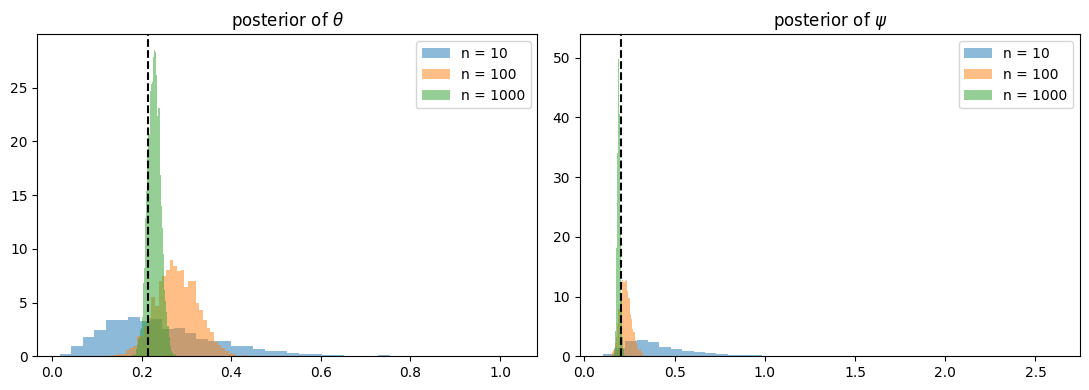

In [7]:
def logpost(xi, gam, X):
    """log of unnormalised posterior g(xi, gamma) = prior(xi, gamma) * likelihood(X)."""
    log_prior = -(xi ** 2 - 2 * rho * xi * gam + gam ** 2) / (2 * (1 - rho ** 2))
    log_lik = np.sum(norm.logpdf(X, loc=np.exp(xi), scale=np.sqrt(np.exp(gam))))
    return log_prior + log_lik


def mh_post(X, n_keep=5000, burn=2000, thin=10, rng=rng):
    """Random-walk Metropolis in (xi, gamma); step shrinks like 1/sqrt(n)."""
    step = 1.0 / np.sqrt(len(X))
    xi = gam = 0.0
    cur = logpost(xi, gam, X)
    out = np.empty((n_keep, 2))
    t = kept = 0
    while kept < n_keep:
        pxi = xi + step * rng.standard_normal()
        pgam = gam + step * rng.standard_normal()
        prop = logpost(pxi, pgam, X)
        if rng.random() < np.exp(prop - cur):
            xi, gam, cur = pxi, pgam, prop
        t += 1
        if t > burn and t % thin == 0:
            out[kept] = [np.exp(xi), np.exp(gam)]
            kept += 1
    return out


fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for n in [10, 100, 1000]:                                  # (d) n=10 and (e) n=100, 1000
    X = rng.normal(theta, np.sqrt(psi), n)
    post = mh_post(X)
    print(f"n = {n:4d}   E[theta|X] = {post[:, 0].mean():.3f}   E[psi|X] = {post[:, 1].mean():.3f}"
          f"      (xbar = {X.mean():.3f},  s^2 = {X.var(ddof=1):.3f})")
    ax[0].hist(post[:, 0], 40, density=True, alpha=0.5, label=f"n = {n}")
    ax[1].hist(post[:, 1], 40, density=True, alpha=0.5, label=f"n = {n}")
ax[0].axvline(theta, color="k", ls="--")
ax[0].set_title(r"posterior of $\theta$")
ax[0].legend()
ax[1].axvline(psi, color="k", ls="--")
ax[1].set_title(r"posterior of $\psi$")
ax[1].legend()
plt.tight_layout()
plt.show()

**Reading Part 3.** As $n$ grows the posterior concentrates around the true $(\theta,\psi)$ (dashed
lines) and its mean tracks $\bar x$ and $s^2$: more data dominates the prior.